[dataset link ](https://www.kaggle.com/datasets/shashwatwork/eeg-psychiatric-disorders-dataset/data)   

In [ ]:
import zipfile
import os

# Path to your ZIP file
zip_path = '/content/archive (2).zip'

# Folder where the contents will be extracted
extract_folder = 'extracted_csv'

# Create folder if it doesn't exist
os.makedirs(extract_folder, exist_ok=True)

# Extract CSV files only
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for file in zip_ref.namelist():
        if file.endswith('.csv'):
            zip_ref.extract(file, extract_folder)
            print(f'Extracted: {file}')


Extracted: EEG.machinelearing_data_BRMH.csv


In [ ]:
import pandas as pd
import os

# Get the full path of the extracted CSV
csv_files = [f for f in os.listdir(extract_folder) if f.endswith('.csv')]
csv_path = os.path.join(extract_folder, csv_files[0])  # First CSV

# Load it
df = pd.read_csv(csv_path)
print(df.head())


   no. sex   age    eeg.date  education     IQ       main.disorder  \
0    1   M  57.0   2012.8.30        NaN    NaN  Addictive disorder   
1    2   M  37.0    2012.9.6        6.0  120.0  Addictive disorder   
2    3   M  32.0   2012.9.10       16.0  113.0  Addictive disorder   
3    4   M  35.0   2012.10.8       18.0  126.0  Addictive disorder   
4    5   M  36.0  2012.10.18       16.0  112.0  Addictive disorder   

      specific.disorder  AB.A.delta.a.FP1  AB.A.delta.b.FP2  ...  \
0  Alcohol use disorder         35.998557         21.717375  ...   
1  Alcohol use disorder         13.425118         11.002916  ...   
2  Alcohol use disorder         29.941780         27.544684  ...   
3  Alcohol use disorder         21.496226         21.846832  ...   
4  Alcohol use disorder         37.775667         33.607679  ...   

   COH.F.gamma.o.Pz.p.P4  COH.F.gamma.o.Pz.q.T6  COH.F.gamma.o.Pz.r.O1  \
0              55.989192              16.739679              23.452271   
1              45.5956

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 945 entries, 0 to 944
Columns: 1149 entries, no. to COH.F.gamma.r.O1.s.O2
dtypes: float64(1144), int64(1), object(4)
memory usage: 8.3+ MB
None


In [ ]:
# Extract EEG feature columns (adjust if necessary)
X = df.iloc[:, 7:]

# Extract label column
y = df['main.disorder']

# Check unique labels
print(y.unique())

['Addictive disorder' 'Trauma and stress related disorder' 'Mood disorder'
 'Healthy control' 'Obsessive compulsive disorder' 'Schizophrenia'
 'Anxiety disorder']


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)


Classes: ['Addictive disorder' 'Anxiety disorder' 'Healthy control' 'Mood disorder'
 'Obsessive compulsive disorder' 'Schizophrenia'
 'Trauma and stress related disorder']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 756
Testing samples: 189


In [ ]:
# Select only numeric columns in X
X_numeric = X.select_dtypes(include=['number'])

print(X_numeric.dtypes)  # Confirm all numeric now

# Then split and train with X_numeric
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


AB.A.delta.a.FP1         float64
AB.A.delta.b.FP2         float64
AB.A.delta.c.F7          float64
AB.A.delta.d.F3          float64
AB.A.delta.e.Fz          float64
                          ...   
COH.F.gamma.p.P4.r.O1    float64
COH.F.gamma.p.P4.s.O2    float64
COH.F.gamma.q.T6.r.O1    float64
COH.F.gamma.q.T6.s.O2    float64
COH.F.gamma.r.O1.s.O2    float64
Length: 1141, dtype: object


RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
                                    precision    recall  f1-score   support

                Addictive disorder       0.30      0.32      0.31        37
                  Anxiety disorder       0.00      0.00      0.00        22
                   Healthy control       0.29      0.11      0.15        19
                     Mood disorder       0.30      0.72      0.42        53
     Obsessive compulsive disorder       1.00      0.11      0.20         9
                     Schizophrenia       0.33      0.04      0.08        23
Trauma and stress related disorder       0.17      0.04      0.06        26

                          accuracy                           0.29       189
                         macro avg       0.34      0.19      0.17       189
                      weighted avg       0.28      0.29      0.22       189

Confusion Matrix:
[[12  3  1 19  0  1  1]
 [ 2  0  1 18  0  0  1]
 [ 7  0  2 10  0  0  0]
 [11  0  2 38  0  0  2]
 [ 1  0  0  7  1  0  0]


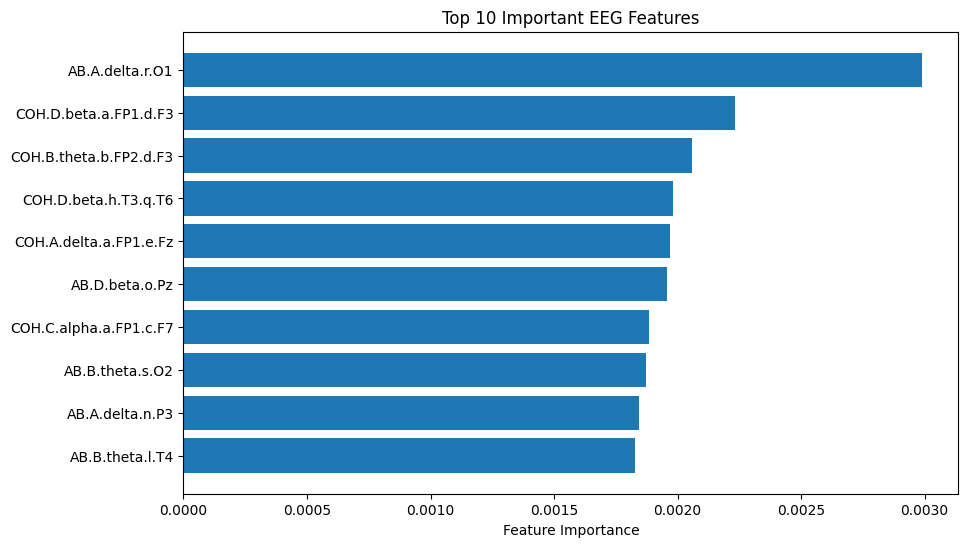

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[-10:]  # top 10 features

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Top 10 Important EEG Features')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne
from math import ceil

In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 76.8 MB/s eta 0:00:00


In [ ]:
chs = {'FP1': [-0.03, 0.08],
       'FP2': [0.03, 0.08],
       'F7': [-0.073, 0.047],
       'F3': [-0.04, 0.041],
       'Fz': [0, 0.038],
       'F4': [0.04, 0.041],
       'F8': [0.073, 0.047],
       'T3': [-0.085, 0],
       'C3': [-0.045, 0],
       'Cz': [0, 0],
       'C4': [0.045, 0],
       'T4': [0.085, 0],
       'T5': [-0.073, -0.047],
       'P3': [-0.04, -0.041],
       'Pz': [0, -0.038],
       'P4': [0.04, -0.041],
       'T6': [0.07, -0.047],
       'O1': [-0.03, -0.08],
       'O2': [0.03, -0.08]}
channels = pd.DataFrame(chs).transpose()
channels

,0,1
FP1,-0.030,0.080
FP2,0.030,0.080
F7,-0.073,0.047
F3,-0.040,0.041
Fz,0.000,0.038
F4,0.040,0.041
F8,0.073,0.047
T3,-0.085,0.000
C3,-0.045,0.000
Cz,0.000,0.000


In [ ]:
# make_dig_montage accepts only 3D coordinates
for key in chs.keys():
    chs[key]+=[0]
chs

{'FP1': [-0.03, 0.08, 0],
 'FP2': [0.03, 0.08, 0],
 'F7': [-0.073, 0.047, 0],
 'F3': [-0.04, 0.041, 0],
 'Fz': [0, 0.038, 0],
 'F4': [0.04, 0.041, 0],
 'F8': [0.073, 0.047, 0],
 'T3': [-0.085, 0, 0],
 'C3': [-0.045, 0, 0],
 'Cz': [0, 0, 0],
 'C4': [0.045, 0, 0],
 'T4': [0.085, 0, 0],
 'T5': [-0.073, -0.047, 0],
 'P3': [-0.04, -0.041, 0],
 'Pz': [0, -0.038, 0],
 'P4': [0.04, -0.041, 0],
 'T6': [0.07, -0.047, 0],
 'O1': [-0.03, -0.08, 0],
 'O2': [0.03, -0.08, 0]}

<ipython-input-19-dd49041d41c7>:2: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  mont.plot()


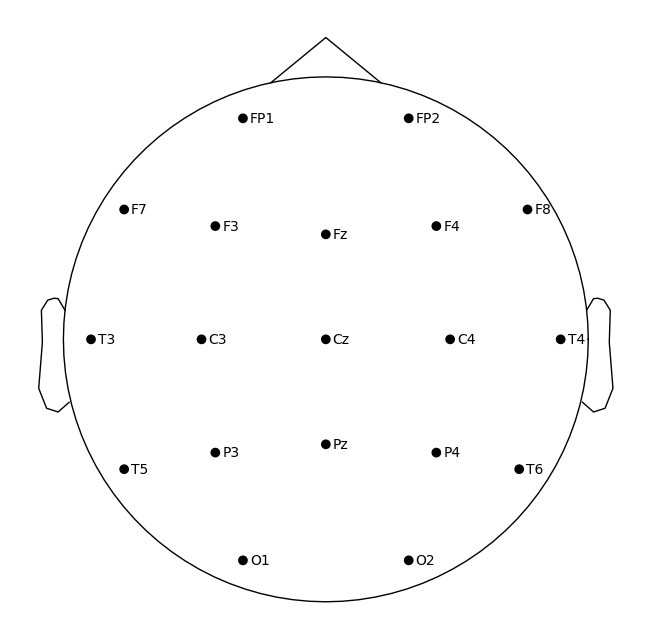

In [ ]:
mont = mne.channels.make_dig_montage(chs)
mont.plot()
plt.show()

In [ ]:
mont = mne.channels.make_dig_montage(chs)
ch_names = list(chs.keys())
info = mne.create_info(ch_names=ch_names, sfreq=256, ch_types='eeg')
info.set_montage(mont)

<ipython-input-20-6b151a82c15a>:4: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  info.set_montage(mont)


<Info | 8 non-empty values
 bads: []
 ch_names: FP1, FP2, F7, F3, Fz, F4, F8, T3, C3, Cz, C4, T4, T5, P3, Pz, ...
 chs: 19 EEG
 custom_ref_applied: False
 dig: 22 items (3 Cardinal, 19 EEG)
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 256.0 Hz
>

In [ ]:
bands = ['delta', 'theta', 'alpha', 'beta', 'highbeta', 'gamma']
disorders = df['main.disorder'].unique()

In [ ]:
from collections import defaultdict

<ipython-input-27-1b610f9ddb81>:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


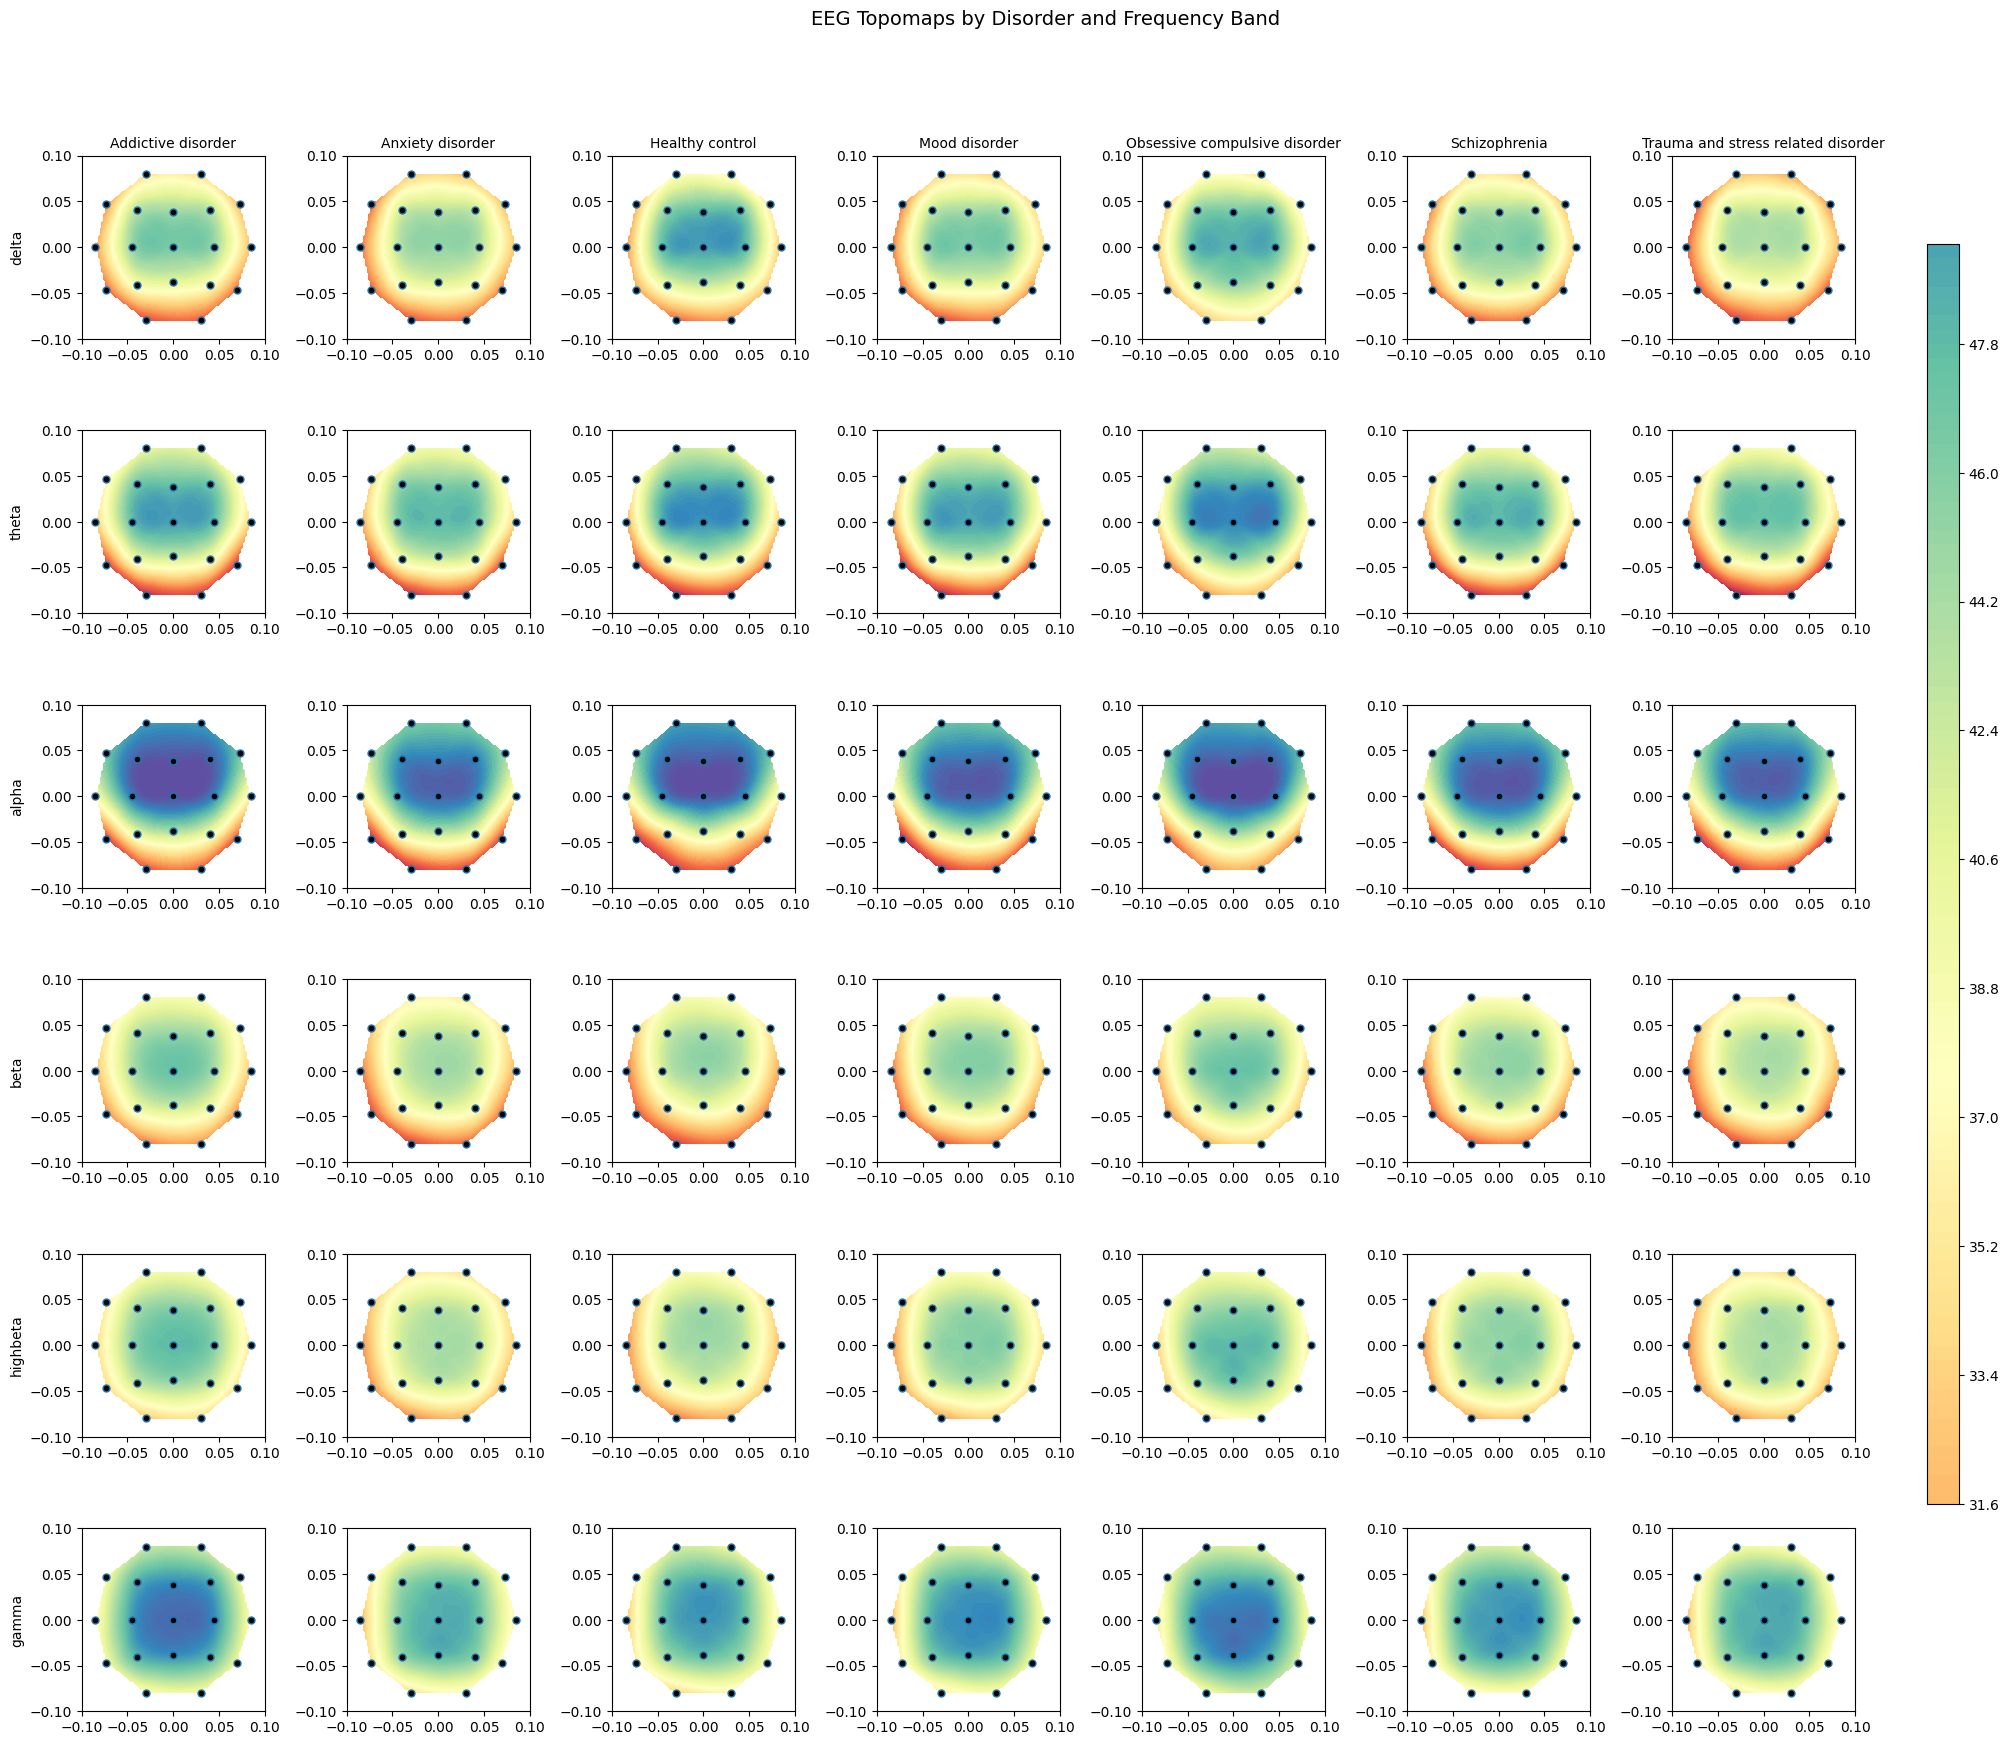

In [ ]:
def plot_eeg(data, pos, ax, fig=None, vmin=None, vmax=None, marker_style=None, cmap='plasma'):
    from scipy.interpolate import griddata
    import numpy as np

    xi = np.linspace(-0.1, 0.1, 100)
    yi = np.linspace(-0.1, 0.1, 100)
    xi, yi = np.meshgrid(xi, yi)

    zi = griddata(pos, data, (xi, yi), method='cubic')

    im = ax.contourf(xi, yi, zi, levels=100, cmap=cmap, vmin=vmin, vmax=vmax)

    if marker_style is None:
        marker_style = {'markersize': 5, 'markerfacecolor': 'black'}
    ax.plot(pos[:, 0], pos[:, 1], 'o', **marker_style)
    ax.set_aspect('equal')
    #ax.axis('off')

    return im
bands = ['delta', 'theta', 'alpha', 'beta', 'highbeta', 'gamma']

main_mean = defaultdict(dict)

for disorder in disorders:
    df_sub = df[df['main.disorder'] == disorder]
    for band in bands:
        channel_values = {}
        for ch in ch_names:
            cols = [col for col in df.columns if band in col and ch in col]
            if cols:
                mean_val = df_sub[cols].mean(axis=1).mean()
                channel_values[ch] = mean_val
        main_mean[disorder][band] = pd.Series(channel_values)

# Get global vmin and vmax for consistent color scaling
all_values = []
for disorder in disorders:
    for band in bands:
        all_values.extend(main_mean[disorder][band].values)
vmin = np.nanmin(all_values)
vmax = np.nanmax(all_values)

# Create plots
fig, axes = plt.subplots(len(bands), len(disorders), figsize=(3 * len(disorders), 3 * len(bands)))

for i, band in enumerate(bands):
    for j, disorder in enumerate(disorders):
        # Handle axes indexing for 1D or 2D
        if len(bands) > 1 and len(disorders) > 1:
            ax = axes[i, j]
        elif len(bands) > 1:
            ax = axes[i]
        elif len(disorders) > 1:
            ax = axes[j]
        else:
            ax = axes  # only one plot

        data = main_mean[disorder][band]
        im = plot_eeg(data, channels.to_numpy(), ax, vmin=vmin, vmax=vmax, cmap='Spectral')

        # Set title for top row
        if i == 0:
            ax.set_title(disorder, fontsize=10)
        # Set ylabel for first column
        if j == 0:
            ax.set_ylabel(band, fontsize=10)


# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax)

plt.suptitle("EEG Topomaps by Disorder and Frequency Band", fontsize=14)
plt.savefig('eeg_topomaps.png', dpi=300)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is the loaded DataFrame with the EEG dataset
# 'main.disorder' column contains the disorder categories
class_counts = df['main.disorder'].value_counts()

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
        colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc', '#99ccff', '#ccff99'])
plt.title('Distribution of Psychiatric Disorder Categories in the Dataset', fontsize=14)
plt.tight_layout()

# Save the plot
plt.savefig('class_distribution.png', dpi=300)
plt.close()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assuming X_numeric is the DataFrame of numeric features (columns 7–1149)
# top_10_features is a DataFrame with the top 10 features from the Random Forest model
importances = model.feature_importances_
top_10_indices = np.argsort(importances)[-10:]
top_10_feature_names = X_numeric.columns[top_10_indices]
X_top_10 = X_numeric[top_10_feature_names]

# Compute the correlation matrix
corr_matrix = X_top_10.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            xticklabels=top_10_feature_names, yticklabels=top_10_feature_names)
plt.title('Correlation Heatmap of Top 10 Important EEG Features', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save the plot
plt.savefig('feature_correlation.png', dpi=300)
plt.close()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import shap
import zipfile
import os


# Step 2: Data Preprocessing
# Separate features and labels
X = df.iloc[:, 7:]  # EEG features (columns 7–1149)
y = df['main.disorder']  # Target variable

# Filter numeric features
X_numeric = X.select_dtypes(include=[np.number])

# Drop columns that are entirely NaN
X_numeric = X_numeric.dropna(axis=1, how='all')
print(f"Dropped columns with all NaN values. Remaining columns: {X_numeric.shape[1]}")

# Check for remaining NaN values and print a warning if any are found
if X_numeric.isna().any().any():
    print(f"Warning: Found {X_numeric.isna().sum().sum()} remaining NaN values in X_numeric. Imputing with mean.")
else:
    print("No remaining NaN values found in X_numeric.")

# Impute remaining NaN values with the mean
imputer = SimpleImputer(strategy='mean')
X_numeric_imputed = pd.DataFrame(imputer.fit_transform(X_numeric), columns=X_numeric.columns)

# Encode the labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric_imputed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=50)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Step 3: Model Training
# Train a Random Forest Classifier with hyperparameter tuning
model = RandomForestClassifier(random_state=50)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(model, param_grid, cv=10, scoring='accuracy')
grid_search.fit(X_train_resampled, y_train_resampled)

# Use the best model
best_model = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")

# Cross-validation
scores = cross_val_score(best_model, X_train_resampled, y_train_resampled, cv=5, scoring='accuracy')
print(f"Cross-validation accuracy scores: {scores}")
print(f"Mean cross-validation accuracy: {scores.mean():.2f} (+/- {scores.std() * 2:.2f})")

# Step 4: Feature Importance (for SHAP, no visualization)
feature_importances = best_model.feature_importances_
feature_names = X_numeric_imputed.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Step 5: Evaluation and Interpretability
# Evaluate the model
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Generate confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Psychiatric Disorder Classification')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.close()

# SHAP analysis for interpretability
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=X_numeric_imputed.columns,
                  plot_type="bar", class_names=le.classes_, show=False)
plt.savefig('feature_importance_shap.png', dpi=300)
plt.close()

print("Pipeline completed successfully!")

Dropped columns with all NaN values. Remaining columns: 1140
No remaining NaN values found in X_numeric.
Best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Cross-validation accuracy scores: [0.65551839 0.7147651  0.74832215 0.79194631 0.87248322]
Mean cross-validation accuracy: 0.76 (+/- 0.15)
Test Accuracy: 0.22
Classification Report:
                                    precision    recall  f1-score   support

                Addictive disorder       0.26      0.24      0.25        37
                  Anxiety disorder       0.06      0.05      0.05        22
                   Healthy control       0.14      0.21      0.17        19
                     Mood disorder       0.37      0.38      0.37        53
     Obsessive compulsive disorder       0.14      0.11      0.12         9
                     Schizophrenia       0.08      0.09      0.09        23
Trauma and stress related disorder       0.17      0.15      0.16        26

                       

In [ ]:
from graphviz import Digraph

# Create a new directed graph
dot = Digraph(comment='EEG Pipeline Flowchart', format='png')

# Set graph attributes for better styling
dot.attr(rankdir='TB')  # Top to Bottom layout
dot.attr('node', shape='box', style='rounded,filled', fillcolor='lightblue', fontsize='10')
dot.attr('edge', color='black', arrowsize='0.8')

# Add nodes for each pipeline step
dot.node('start', 'Start', shape='ellipse', fillcolor='lightgreen')
dot.node('acquire', 'Data Acquisition\n(Extract & Load CSV)')
dot.node('preprocess', 'Data Preprocessing\n(Filter, Impute, Encode, Split)')
dot.node('smote', 'Handle Class Imbalance\n(SMOTE)')
dot.node('train', 'Model Training\n(Random Forest with Tuning)')
dot.node('evaluate', 'Evaluation\n(Accuracy, Confusion Matrix)')
dot.node('interpret', 'Interpretability\n(SHAP Analysis)')
dot.node('end', 'End', shape='ellipse', fillcolor='lightcoral')

# Add edges to connect the nodes
dot.edge('start', 'acquire')
dot.edge('acquire', 'preprocess')
dot.edge('preprocess', 'smote')
dot.edge('smote', 'train')
dot.edge('train', 'evaluate')
dot.edge('evaluate', 'interpret')
dot.edge('interpret', 'end')

# Render the flowchart to a file
dot.render('pipeline_flowchart', view=False, cleanup=True)
print("Flowchart generated as 'pipeline_flowchart.png' in the current directory.")

Flowchart generated as 'pipeline_flowchart.png' in the current directory.
